In [ ]:
# ! pip install pandas openpyxl
# ! pip install seaborn
# ! pip install streamlit seaborn matplotlib pandas

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import unicodedata
import re

In [37]:
# Ler a planilha da Marcelina
file_path = r"C:\Users\wnsos\OneDrive\Escritorio\Claro\Cluster_projeto_area_tecnica\cluster_marcelina.xlsx"
df = pd.read_excel(file_path, sheet_name="cluster_marcelina")

# Ver primeiras linhas
df.head()

,COD_NODE,REGIONAL,COD_IBGE,DESC_CIDADE,DESC_COD_CIDADE,CLUSTER_GEOGRAFICO,AREA,Area_Tecnica,HP_TECNICA
0,JDA0040307,SP1,3556503,VARZEA PAULISTA,GRANDE SÃO PAULO,JUNDIAI,Metropolitana (Área 3),AREA VARZEA PAU,13.0
1,JDA0040308,SP1,3556503,VARZEA PAULISTA,GRANDE SÃO PAULO,JUNDIAI,Metropolitana (Área 3),AREA VARZEA PAU,19.0
2,JDA0040401,SP1,3556503,VARZEA PAULISTA,GRANDE SÃO PAULO,JUNDIAI,Metropolitana (Área 3),AREA VARZEA PAU,18.0
3,JDA0040402,SP1,3556503,VARZEA PAULISTA,GRANDE SÃO PAULO,JUNDIAI,Metropolitana (Área 3),AREA VARZEA PAU,17.0
4,JDA0040403,SP1,3556503,VARZEA PAULISTA,GRANDE SÃO PAULO,JUNDIAI,Metropolitana (Área 3),AREA VARZEA PAU,19.0


In [38]:
# Ler a planilha da Técnica
file_path = r"C:\Users\wnsos\OneDrive\Escritorio\Claro\Cluster_projeto_area_tecnica\Base_Qualinet.xlsx"
df_tec = pd.read_excel(file_path, sheet_name="Planilha1")

# Ver primeiras linhas
df_tec.head()

,PERÍODO,REGIONAL,SIGLA,SUBCLUSTER,CIDADE,AREA,NODE,GRUPO,HPs,DOMICILIO,PAYTV,PTV DIGITAL,PTV HD,VIRTUA,NETFONE,EBT PME,COD CIDADE + AREA
0,2026-02-01,TODAS,AMIO,SUBCLUSTER SÃO ROQUE,ALUMINIO,AREA ALUMINIO,3501152-SP,-,-,63,0,0,45,0,0,0,535 AREA ALUMINIO
1,2026-02-01,TODAS,AMIO,SUBCLUSTER SÃO ROQUE,ALUMINIO,AREA ALUMINIO,VLP0010101,-,22,7,0,0,1,7,3,0,535 AREA ALUMINIO
2,2026-02-01,TODAS,AMIO,SUBCLUSTER SÃO ROQUE,ALUMINIO,AREA ALUMINIO,VLP0010102,-,10,4,0,0,0,4,2,0,535 AREA ALUMINIO
3,2026-02-01,TODAS,AMIO,SUBCLUSTER SÃO ROQUE,ALUMINIO,AREA ALUMINIO,VLP0010103,-,17,7,0,0,0,7,1,0,535 AREA ALUMINIO
4,2026-02-01,TODAS,AMIO,SUBCLUSTER SÃO ROQUE,ALUMINIO,AREA ALUMINIO,VLP0010104,-,17,7,0,0,1,7,4,0,535 AREA ALUMINIO


In [39]:
# Padronizar nomes das cidades

def normalizar_texto(texto):
    if pd.isnull(texto):
        return texto
    
    # remover acentos
    texto = unicodedata.normalize('NFKD', texto)
    texto = texto.encode('ASCII', 'ignore').decode('utf-8')
    
    # remover espaços duplicados
    texto = re.sub(r'\s+', ' ', texto)
    
    # strip e upper
    texto = texto.strip().upper()
    
    return texto

In [40]:
# Aplicar a função de normalização nas colunas de cidade

df_tec['CIDADE_NORM'] = df_tec['CIDADE'].apply(normalizar_texto)
df['DESC_CIDADE_NORM'] = df['DESC_CIDADE'].apply(normalizar_texto)

In [41]:
# Validar se existe cidade no df_tec que não existe no df

cidades_tec = set(df_tec['CIDADE_NORM'].unique())
cidades_ref = set(df['DESC_CIDADE_NORM'].unique())

cidades_nao_encontradas = cidades_tec - cidades_ref

print("Cidades não encontradas:")
print(cidades_nao_encontradas)

Cidades não encontradas:
set()


In [42]:
# Verififcar se há duplicidade no COD_IBGE

df.groupby('DESC_CIDADE_NORM')['COD_IBGE'].nunique().sort_values(ascending=False).head(10)

DESC_CIDADE_NORM
ALUMINIO                1
ARUJA                   1
ATIBAIA                 1
BARUERI                 1
BRAGANCA PAULISTA       1
CABREUVA                1
CAIEIRAS                1
CAJAMAR                 1
CAMPO LIMPO PAULISTA    1
CARAPICUIBA             1
Name: COD_IBGE, dtype: int64

In [44]:
# Passar o COD_IBGE para a base técnica

df_ref = (
    df[['DESC_CIDADE_NORM', 'COD_IBGE']]
    .drop_duplicates(subset='DESC_CIDADE_NORM')
)

mapa_ibge = df_ref.set_index('DESC_CIDADE_NORM')['COD_IBGE']

df_tec['COD_IBGE'] = df_tec['CIDADE_NORM'].map(mapa_ibge)

In [47]:
# verificar quantos valores nulos existem na coluna COD_IBGE após o merge
df_tec['COD_IBGE'].isnull().sum()

np.int64(0)

In [48]:
# Padronizar NODE nas duas bases

def normalizar_node(texto):
    if pd.isnull(texto):
        return texto
    
    texto = str(texto).strip().upper()
    return texto

In [49]:
# Padropnizar o nome das colunas, que tem colunas com espaços nos nomes

df_tec.columns = df_tec.columns.str.strip().str.upper()
df.columns = df.columns.str.strip().str.upper()

In [50]:
df_tec['COD_NODE_NORM'] = df_tec['NODE'].apply(normalizar_node)
df['COD_NODE_NORM'] = df['COD_NODE'].apply(normalizar_node)

In [51]:
# Conferir diferenças entre as bases

nodes_tec = set(df_tec['COD_NODE_NORM'].dropna().unique())
nodes_ref = set(df['COD_NODE_NORM'].dropna().unique())

nodes_somente_tec = nodes_tec - nodes_ref
nodes_somente_ref = nodes_ref - nodes_tec

print("Nodes apenas no df_tec:", len(nodes_somente_tec))
print("Nodes apenas no df:", len(nodes_somente_ref))

Nodes apenas no df_tec: 3259
Nodes apenas no df: 3228


In [52]:
# Criar nova variável COD_NODE + COD_IBGE

df_tec['COD_IBGE'] = df_tec['COD_IBGE'].astype('Int64')
df_tec['COD_IBGE_STR'] = df_tec['COD_IBGE'].astype(str)

df['COD_IBGE'] = df['COD_IBGE'].astype('Int64')
df['COD_IBGE_STR'] = df['COD_IBGE'].astype(str)

df_tec['CHAVE_NODE_IBGE'] = (
    df_tec['COD_NODE_NORM'] + "_" + df_tec['COD_IBGE_STR']
)

df['CHAVE_NODE_IBGE'] = (
    df['COD_NODE_NORM'] + "_" + df['COD_IBGE_STR']
)

In [53]:
# Verificar quantos valores nulos existem na nova chave

resumo = {
    "df_tec_total": len(df_tec),
    "df_tec_cod_ibge_null": df_tec['CHAVE_NODE_IBGE'].isnull().sum(),
    "df_total": len(df),
    "df_cod_node_null": df['CHAVE_NODE_IBGE'].isnull().sum()
}

resumo

{'df_tec_total': 30260,
 'df_tec_cod_ibge_null': np.int64(0),
 'df_total': 30542,
 'df_cod_node_null': np.int64(0)}

In [56]:
# Validar unicidade da chave CHAVE_NODE_IBGE na df_tec

df_tec['CHAVE_NODE_IBGE'].is_unique

True

In [57]:
# Preparar para criar a coluna Area na base de negócio a partir da base técnica

mapa_area = df_tec.set_index('CHAVE_NODE_IBGE')['AREA']

df['AREA_TECNICA'] = df['CHAVE_NODE_IBGE'].map(mapa_area)

In [58]:
# Verificar quantas ficaram sem área técnica atribuída

df['AREA_TECNICA'].isnull().sum()

np.int64(3459)

In [59]:
df[df['AREA_TECNICA'].isnull()][['CHAVE_NODE_IBGE']]

,CHAVE_NODE_IBGE
9,JDA0050102_3556503
17,JDA0050301_3556503
18,JDA0050302_3556503
20,JDA0050304_3556503
21,JDA0050305_3556503
...,...
30456,VJAAAM_3550308
30457,VJAABM_3550308
30458,VJAAF_3550308
30514,VLA0010307_3523107


In [60]:
df.head()

,COD_NODE,REGIONAL,COD_IBGE,DESC_CIDADE,DESC_COD_CIDADE,CLUSTER_GEOGRAFICO,AREA,AREA_TECNICA,HP_TECNICA,DESC_CIDADE_NORM,COD_NODE_NORM,COD_IBGE_STR,CHAVE_NODE_IBGE
0,JDA0040307,SP1,3556503,VARZEA PAULISTA,GRANDE SÃO PAULO,JUNDIAI,Metropolitana (Área 3),AREA VARZEA PAU,13.0,VARZEA PAULISTA,JDA0040307,3556503,JDA0040307_3556503
1,JDA0040308,SP1,3556503,VARZEA PAULISTA,GRANDE SÃO PAULO,JUNDIAI,Metropolitana (Área 3),AREA VARZEA PAU,19.0,VARZEA PAULISTA,JDA0040308,3556503,JDA0040308_3556503
2,JDA0040401,SP1,3556503,VARZEA PAULISTA,GRANDE SÃO PAULO,JUNDIAI,Metropolitana (Área 3),AREA VARZEA PAU,18.0,VARZEA PAULISTA,JDA0040401,3556503,JDA0040401_3556503
3,JDA0040402,SP1,3556503,VARZEA PAULISTA,GRANDE SÃO PAULO,JUNDIAI,Metropolitana (Área 3),AREA VARZEA PAU,17.0,VARZEA PAULISTA,JDA0040402,3556503,JDA0040402_3556503
4,JDA0040403,SP1,3556503,VARZEA PAULISTA,GRANDE SÃO PAULO,JUNDIAI,Metropolitana (Área 3),AREA VARZEA PAU,19.0,VARZEA PAULISTA,JDA0040403,3556503,JDA0040403_3556503


In [67]:
# Verificar quantas chaves cada cidade possui

df_tec.groupby('CIDADE')['CHAVE_NODE_IBGE'].nunique().sort_values(ascending=False)

CIDADE
SAO PAULO                 4570
ARUJA                     3201
ITATIBA                   2512
VARZEA PAULISTA           2082
ITUPEVA                   1937
CAMPO LIMPO PAULISTA      1806
SÃO ROQUE                 1796
RIBEIRAO PIRES            1498
JARINU                    1290
ITAQUAQUECETUBA           1278
CAIEIRAS                  1068
OSASCO                     825
CAJAMAR                    613
SAO BERNARDO DO CAMPO      487
GUARULHOS                  484
CABREUVA                   444
BARUERI                    407
SANTO ANDRE                404
JUNDIAI                    365
MAIRINQUE                  327
ALUMINIO                   324
MOGI DAS CRUZES            297
CARAPICUIBA                230
DIADEMA                    212
SAO CAETANO DO SUL         207
COTIA                      198
MAUA                       165
TABOAO DA SERRA            130
SANTANA DE PARNAIBA        128
BRAGANÇA PAULISTA          122
ITU                        113
SALTO                      110
S

In [72]:
# Tratar a coluna de HP antes

df['HP_TECNICA'] = (
    pd.to_numeric(df['HP_TECNICA'], errors='coerce')  
    .fillna(0)                                       
    .astype(int)                                   
)

In [73]:
df['HP_TECNICA'].dtype
df['HP_TECNICA'].isnull().sum()

np.int64(0)

In [75]:
# Exportar a base final para Excel e rodar no app do Stramlit

print("Total de linhas:", len(df))
print("Colunas:", df.columns.tolist())
print("Valores nulos:\n", df.isnull().sum())

df.to_csv(r"C:\Users\wnsos\OneDrive\Escritorio\Claro\Cluster_projeto_area_tecnica\cluster_marcelina_limpo.csv", index=False, sep=";", encoding="utf-8-sig")

Total de linhas: 30542
Colunas: ['COD_NODE', 'REGIONAL', 'COD_IBGE', 'DESC_CIDADE', 'DESC_COD_CIDADE', 'CLUSTER_GEOGRAFICO', 'AREA', 'AREA_TECNICA', 'HP_TECNICA', 'DESC_CIDADE_NORM', 'COD_NODE_NORM', 'COD_IBGE_STR', 'CHAVE_NODE_IBGE']
Valores nulos:
 COD_NODE                 0
REGIONAL                 0
COD_IBGE                 0
DESC_CIDADE              0
DESC_COD_CIDADE          0
CLUSTER_GEOGRAFICO       0
AREA                     0
AREA_TECNICA          3459
HP_TECNICA               0
DESC_CIDADE_NORM         0
COD_NODE_NORM            0
COD_IBGE_STR             0
CHAVE_NODE_IBGE          0
dtype: int64


In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30542 entries, 0 to 30541
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   COD_NODE            30542 non-null  str    
 1   REGIONAL            30542 non-null  str    
 2   COD_IBGE            30542 non-null  Int64  
 3   DESC_CIDADE         30542 non-null  str    
 4   DESC_COD_CIDADE     30542 non-null  str    
 5   CLUSTER_GEOGRAFICO  30542 non-null  str    
 6   AREA                30542 non-null  str    
 7   AREA_TECNICA        27083 non-null  str    
 8   HP_TECNICA          27082 non-null  float64
 9   DESC_CIDADE_NORM    30542 non-null  str    
 10  COD_NODE_NORM       30542 non-null  str    
 11  COD_IBGE_STR        30542 non-null  str    
 12  CHAVE_NODE_IBGE     30542 non-null  str    
dtypes: Int64(1), float64(1), str(11)
memory usage: 6.5 MB


In [62]:
total_ausentes = df['AREA_TECNICA'].isna().sum()
print(f"Valores ausentes em 'ÁREA TÉCNICA': {total_ausentes}")

Valores ausentes em 'ÁREA TÉCNICA': 3459


In [63]:
df.isna().sum()

COD_NODE                 0
REGIONAL                 0
COD_IBGE                 0
DESC_CIDADE              0
DESC_COD_CIDADE          0
CLUSTER_GEOGRAFICO       0
AREA                     0
AREA_TECNICA          3459
HP_TECNICA            3460
DESC_CIDADE_NORM         0
COD_NODE_NORM            0
COD_IBGE_STR             0
CHAVE_NODE_IBGE          0
dtype: int64

In [64]:
# Quantidade de Area Tecnica com dados faltantes

round(100 * df["AREA_TECNICA"].isna().sum() / len(df), 2)

np.float64(11.33)

In [76]:
# Remover N/D temporariamente

df_valid = df.dropna(subset=["AREA_TECNICA", "HP_TECNICA"])

In [77]:
# Criar matriz percentual

# Garantir que HP é numérico
df_valid["HP_TECNICA"] = pd.to_numeric(df_valid["HP_TECNICA"], errors="coerce")

# Criar pivot com soma de HP
matriz = df_valid.pivot_table(
    index="AREA_TECNICA",
    columns="CLUSTER_GEOGRAFICO",
    values="HP_TECNICA",
    aggfunc="sum",
    fill_value=0   # 🔥 já evita missing na soma
)

# Calcular percentual dentro da área
matriz_pct = matriz.div(matriz.sum(axis=1), axis=0) * 100

# Substituir possíveis NaN por 0 (caso alguma área tivesse total zero)
matriz_pct = matriz_pct.fillna(0)

# Arredondar para 1 casa decimal
matriz_pct = matriz_pct.round(1)

matriz_pct.head()

CLUSTER_GEOGRAFICO,ABCDM,GUARULHOS,JUNDIAI,OSASCO,SP
AREA_TECNICA,,,,,
AREA 01,20.5,10.4,0.0,41.0,28.1
AREA 02,23.0,0.0,0.0,35.9,41.1
AREA 03,0.0,0.0,0.9,99.1,0.0
AREA 04,35.5,0.0,0.0,24.0,40.4
AREA 05,0.0,0.0,0.0,0.0,100.0


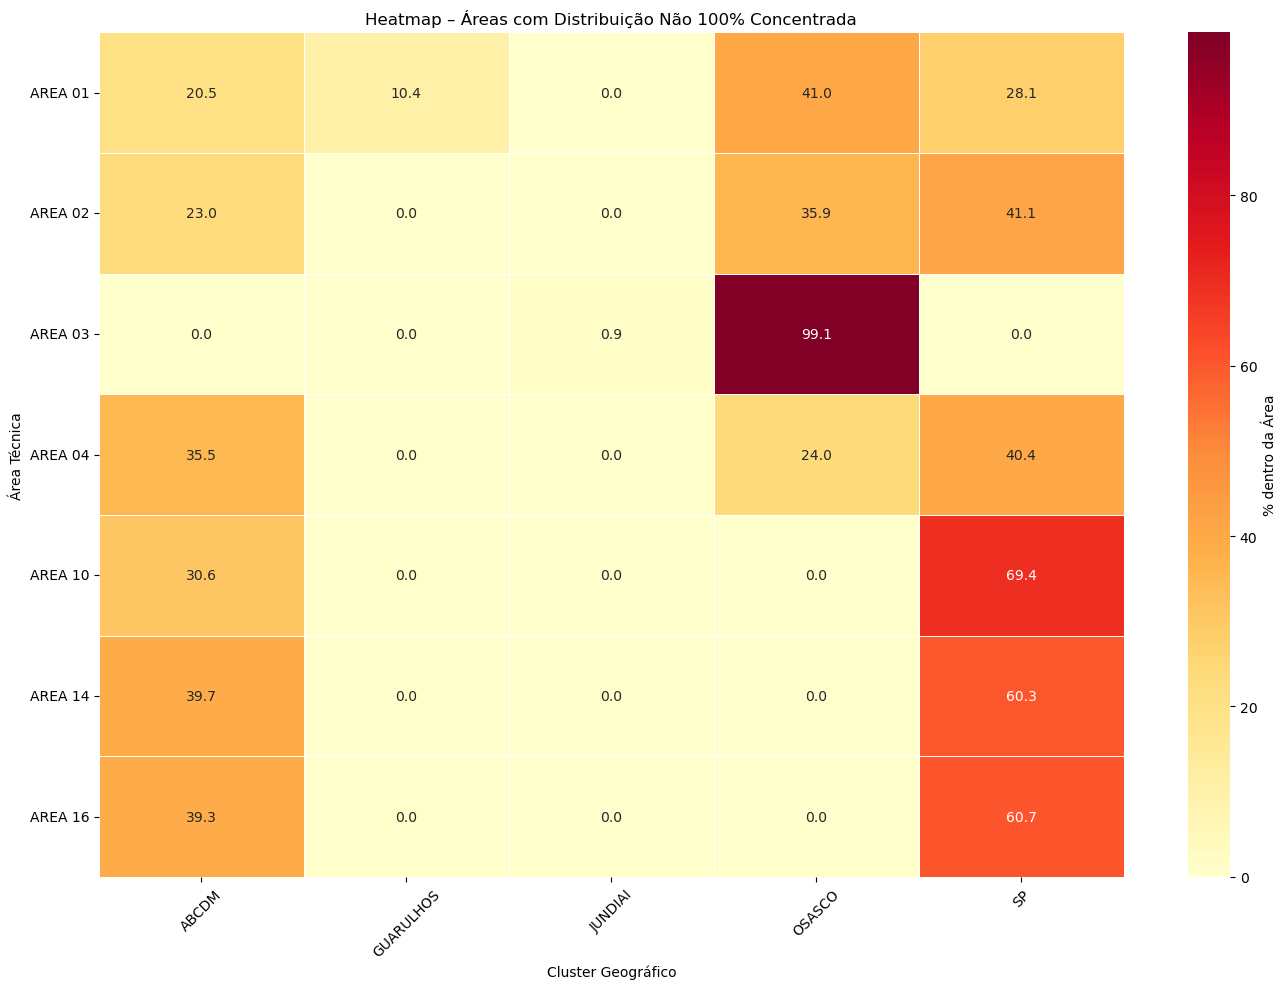

In [78]:
# Identificar concentração máxima por área
max_por_area = matriz_pct.max(axis=1)

# Filtrar apenas áreas que NÃO são 100% concentradas
matriz_parcial = matriz_pct[max_por_area < 100].copy()

plt.figure(figsize=(14, 10))

sns.heatmap(
    matriz_parcial,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "% dentro da Área"}
)

plt.title("Heatmap – Áreas com Distribuição Não 100% Concentrada")
plt.xlabel("Cluster Geográfico")
plt.ylabel("Área Técnica")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

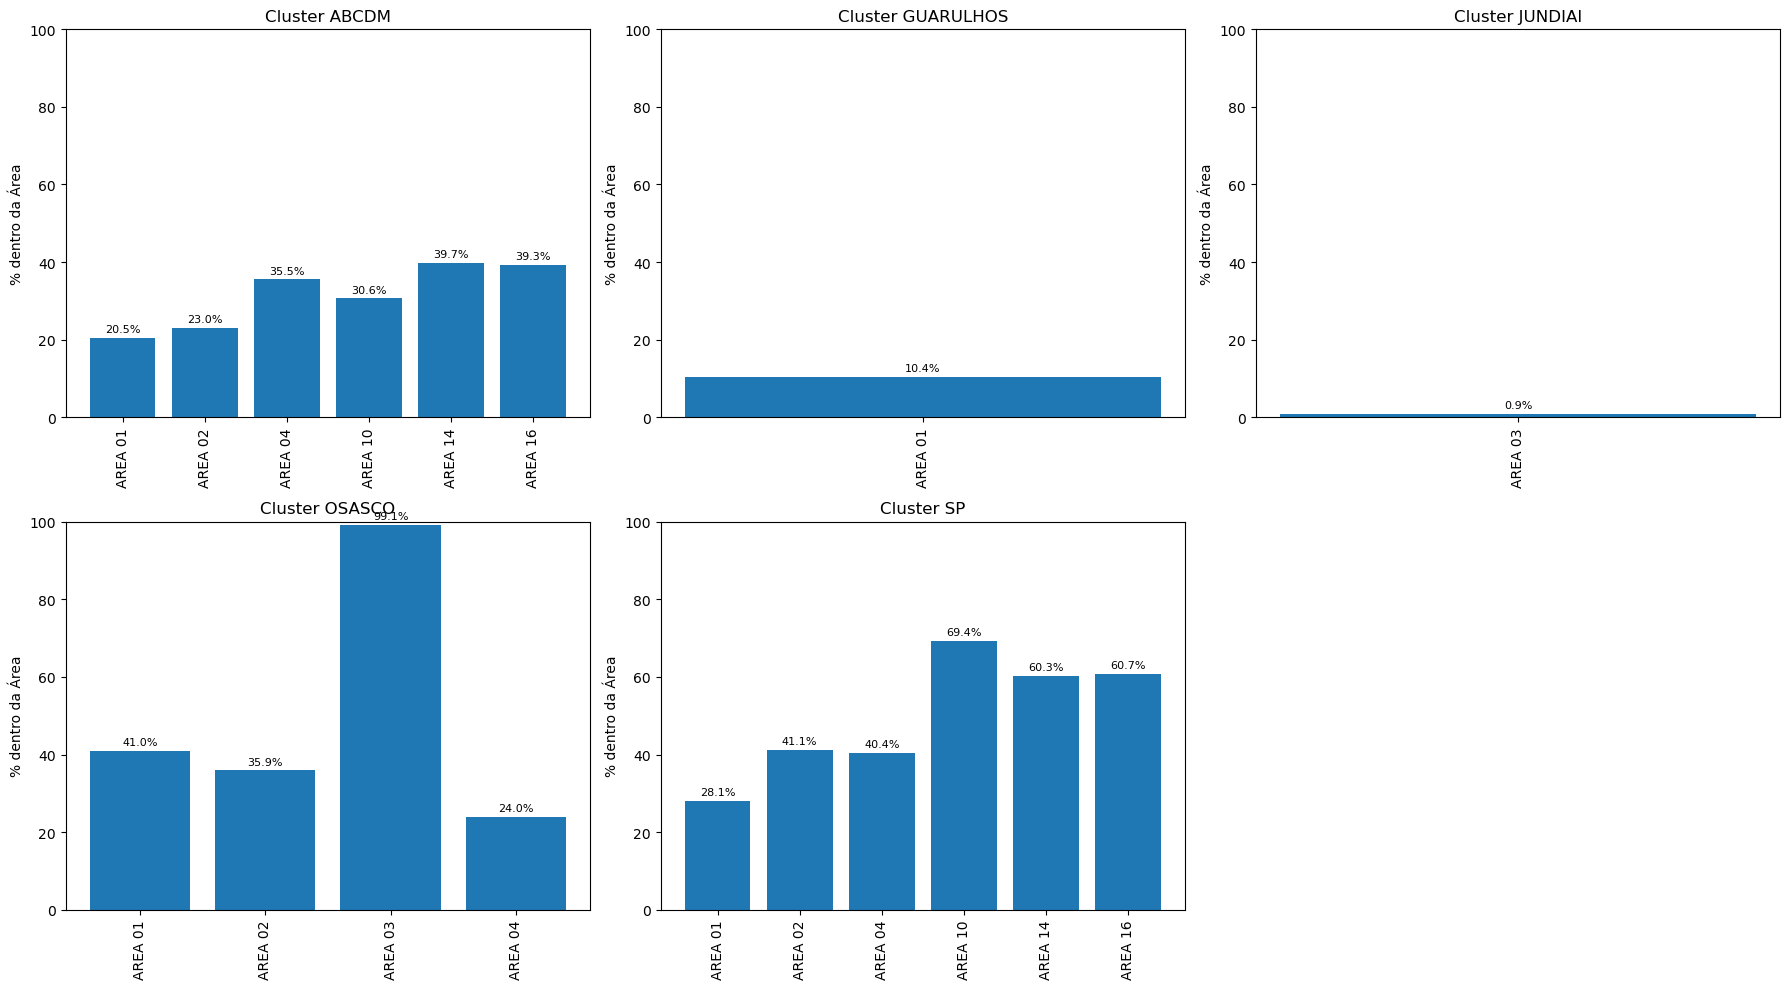

In [79]:
# Identificar áreas 100% concentradas
max_por_area = matriz_pct.max(axis=1)

# Manter apenas áreas NÃO 100%
matriz_nao_100 = matriz_pct[max_por_area < 100].copy()

clusters = matriz_nao_100.columns
n_clusters = len(clusters)

# Layout automático
n_cols = 3
n_rows = math.ceil(n_clusters / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, cluster in enumerate(clusters):
    
    data = matriz_nao_100[cluster]
    data = data[data > 0].sort_index()  # 🔥 ordem alfabética

    bars = axes[i].bar(data.index, data.values)

    axes[i].set_title(f"Cluster {cluster}")
    axes[i].set_ylim(0, 100)
    axes[i].set_ylabel("% dentro da Área")
    axes[i].tick_params(axis='x', rotation=90)

    # Rótulos
    for bar in bars:
        height = bar.get_height()
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.1f}%",
            ha='center',
            va='bottom',
            fontsize=8
        )

# Remover eixos vazios
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [80]:
# Identificar áreas 100%
max_por_area = matriz_pct.max(axis=1)

areas_100 = matriz_pct[max_por_area == 100].copy()

# Transformar para formato longo
areas_100_long = (
    areas_100
    .stack()
    .reset_index()
)

areas_100_long.columns = ["AREA_TECNICA", "CLUSTER_GEOGRAFICO", "PERCENTUAL"]

# Manter apenas onde é 100%
areas_100_long = areas_100_long[areas_100_long["PERCENTUAL"] == 100]

# Adicionar HP total da área
hp_total_area = matriz.sum(axis=1)

areas_100_long["HP_TOTAL"] = areas_100_long["AREA_TECNICA"].map(hp_total_area)

# 🔥 Reordenar colunas (Cluster primeiro)
areas_100_long = areas_100_long[
    ["CLUSTER_GEOGRAFICO", "AREA_TECNICA", "HP_TOTAL"]
]

# Ordenar por cluster e depois por HP decrescente
areas_100_long = areas_100_long.sort_values(
    ["CLUSTER_GEOGRAFICO", "HP_TOTAL"],
    ascending=[True, False]
)

areas_100_long.head()

,CLUSTER_GEOGRAFICO,AREA_TECNICA,HP_TOTAL
5,ABCDM,AREA 08,127193
20,ABCDM,AREA 12,120627
10,ABCDM,AREA 09,97888
255,ABCDM,AREA RIBEIRAO P,18178
46,GUARULHOS,AREA 2,236829
